In [1]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_no_maxpooling import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730
Epoch   0 | train: 0.8931 | val: 0.4850 | acc: 94.80% | AUC: 0.851
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling.pth
Epoch   1 | train: 0.4473 | val: 0.3621 | acc: 89.92% | AUC: 0.906
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling.pth
Epoch   2 | train: 0.3868 | val: 0.3792 | acc: 87.73% | AUC: 0.916
Epoch   3 | train: 0.3698 | val: 0.3568 | acc: 88.65% | AUC: 0.919
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling.pth
Epoch   4 | train: 0.3603 | val: 0.3756 | acc: 85.94% | AUC: 0.917
Epoch   5 | train: 0.3481 | val: 0.3359 | acc: 90.27% | AUC: 0.920
  -> ny bästa modell sparad till ../models/convolution_model_no_max_pooling.pth
Epoch   6 | train: 0.3372 | val: 0.3588 | acc: 85.22% | AUC: 0.924
Epoch   7 | train: 0.3319 | val: 0.3141 | acc: 90.39% | AUC: 0.927
  -> ny bästa modell sparad till ../models/convolution

              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.98      7146
     Positiv       0.78      0.89      0.83       586

    accuracy                           0.97      7732
   macro avg       0.88      0.93      0.91      7732
weighted avg       0.97      0.97      0.97      7732

[[6995  151]
 [  65  521]]
AUC: 0.983659561806457
Accuracy:  97.21%
FN-rate:   11.09%  (farliga missade fall)
FP-rate:   2.11%  (onödiga larm)
Sensitivitet:   88.91%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.89%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9837


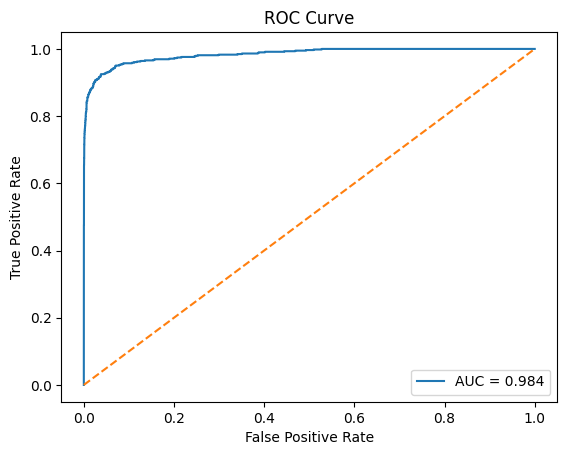

In [2]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)